## Подключение библиотек

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Подготовка и очистка данных

In [50]:
df_prolong = pd.read_csv('prolongations.csv')
df_financial = pd.read_csv('financial_data.csv')
df_prolong.info()
df_financial.info()

<class 'pandas.DataFrame'>
RangeIndex: 477 entries, 0 to 476
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      477 non-null    int64
 1   month   477 non-null    str  
 2   AM      477 non-null    str  
dtypes: int64(1), str(2)
memory usage: 11.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id             451 non-null    int64
 1   Причина дубля  301 non-null    str  
 2   Ноябрь 2022    156 non-null    str  
 3   Декабрь 2022   159 non-null    str  
 4   Январь 2023    139 non-null    str  
 5   Февраль 2023   145 non-null    str  
 6   Март 2023      168 non-null    str  
 7   Апрель 2023    174 non-null    str  
 8   Май 2023       190 non-null    str  
 9   Июнь 2023      190 non-null    str  
 10  Июль 2023      195 non-null    str  
 11  Август 2023    199 non-null    str  
 12

In [51]:
def clean_currency(value):
    if pd.isna(value) or value == '':
        return 0.0
    
    val_str = str(value).strip().lower().replace('\xa0', '').replace(' ', '')
    
    if val_str in ['стоп', 'вноль', 'end']:
        return val_str
    
    try:
        clean_val = val_str.replace(',', '.')
        return float(clean_val)
    except ValueError:
        return 0.0 

In [52]:
month_columns = df_financial.columns[2:-1]

for col in month_columns:
    df_financial[col] = df_financial[col].apply(clean_currency)

df_financial_numeric = df_financial.copy()
for col in month_columns:
    df_financial_numeric[col] = pd.to_numeric(df_financial_numeric[col], errors='coerce').fillna(0)

df_financial_grouped = df_financial_numeric.groupby('id')[month_columns].sum().reset_index()

df_financial_markers = df_financial.groupby('id')[month_columns].apply(lambda x: x.astype(str).agg(' '.join)).reset_index()

df_merged = pd.merge(df_prolong, df_financial_grouped, on='id', how='left')
df_merged['month'] = df_merged['month'].str.capitalize()

df_merged = pd.merge(df_merged, df_financial_markers, on='id', how='left', suffixes=('', '_status'))

df_merged = df_merged.fillna(0)
df_merged

,id,month,AM,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,...,Май 2023_status,Июнь 2023_status,Июль 2023_status,Август 2023_status,Сентябрь 2023_status,Октябрь 2023_status,Ноябрь 2023_status,Декабрь 2023_status,Январь 2024_status,Февраль 2024_status
0,42,Ноябрь 2022,Васильев Артем Александрович,36220.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,453,Ноябрь 2022,Васильев Артем Александрович,0.0,39245.0,44320.0,177635.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,548,Ноябрь 2022,Михайлов Андрей Сергеевич,674000.0,674000.0,674000.0,674000.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,87,Ноябрь 2022,Соколова Анастасия Викторовна,70050.0,0.0,73380.0,83480.0,89300.0,89300.0,78605.0,...,78605.0,72485.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,429,Ноябрь 2022,Соколова Анастасия Викторовна,30280.0,35580.0,35830.0,42830.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
472,955,Декабрь 2023,Смирнова Ольга Владимировна,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,9300.0,9300.0,13200.0,17400.0,0.0,0.0
473,1004,Декабрь 2023,без А/М,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,34000.0,0.0,0.0,0.0
474,281,Декабрь 2023,Соколова Анастасия Викторовна,98000.0,93250.0,82800.0,109000.0,125800.0,91750.0,94700.0,...,78800.0 15900.0,126740.0 3000.0,117730.0 0.0,115860.0 0.0,160770.0 0.0,142490.0 0.0,99125.0 0.0,74350.0 0.0,105775.0 0.0,92065.0 0.0
475,785,Декабрь 2023,Соколова Анастасия Викторовна,0.0,0.0,0.0,5306.6,12898.1,5287.0,10180.0,...,10180.0,8600.0,3860.0,8600.0,700.0,700.0,вноль,вноль,0.0,0.0


In [53]:
ids_to_drop = []
chronological_months = list(month_columns)

for index, row in df_merged.iterrows():
    end_month = row['month']
    if end_month not in chronological_months:
        continue
    
    end_idx = chronological_months.index(end_month)
    
    for i in range(end_idx + 1):
        status_col = chronological_months[i] + '_status'
        if status_col in df_merged.columns:
            status_text = str(row[status_col])
            if 'стоп' in status_text or 'end' in status_text:
                ids_to_drop.append(row['id'])
                break 

df_merged = df_merged[~df_merged['id'].isin(ids_to_drop)]

print(f"Удалено проектов из-за 'стоп'/'end': {len(set(ids_to_drop))}")
print(f"Осталось проектов для расчета: {len(df_merged)}")
df_merged.info()

Удалено проектов из-за 'стоп'/'end': 46
Осталось проектов для расчета: 413
<class 'pandas.DataFrame'>
Index: 413 entries, 0 to 476
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    413 non-null    int64  
 1   month                 413 non-null    str    
 2   AM                    413 non-null    str    
 3   Ноябрь 2022           413 non-null    float64
 4   Декабрь 2022          413 non-null    float64
 5   Январь 2023           413 non-null    float64
 6   Февраль 2023          413 non-null    float64
 7   Март 2023             413 non-null    float64
 8   Апрель 2023           413 non-null    float64
 9   Май 2023              413 non-null    float64
 10  Июнь 2023             413 non-null    float64
 11  Июль 2023             413 non-null    float64
 12  Август 2023           413 non-null    float64
 13  Сентябрь 2023         413 non-null    float64
 14  Октябрь 2023   

## Расчёт коэффициента пролонгации

In [54]:
df_merged['month'] = df_merged['month'].str.capitalize()
report_months_2023 = [m for m in chronological_months if '2023' in m]

print("Месяцы для отчета:", report_months_2023)

Месяцы для отчета: ['Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023', 'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023', 'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023']


In [55]:
metrics_data = []

for report_month in report_months_2023:
    idx = chronological_months.index(report_month)
    
    m1_month = chronological_months[idx - 1] if idx >= 1 else None
    m2_month = chronological_months[idx - 2] if idx >= 2 else None
    
    for am in df_merged['AM'].unique():
        k1_num, k1_denom = 0.0, 0.0
        k2_num, k2_denom = 0.0, 0.0
        
        if m1_month:
            k1_projects = df_merged[(df_merged['AM'] == am) & (df_merged['month'] == m1_month)]
            for _, proj in k1_projects.iterrows():
                base_sum = proj[m1_month]
                status_text = str(proj[m1_month + '_status']).lower().replace(' ', '')
                if base_sum == 0 and 'ноль' in status_text:
                    if idx >= 2:
                        base_sum = proj[chronological_months[idx - 2]]
                
                k1_denom += base_sum
                k1_num += proj[report_month]

        if m2_month and m1_month:
            k2_projects = df_merged[
                (df_merged['AM'] == am) & 
                (df_merged['month'] == m2_month) & 
                (df_merged[m1_month] == 0)
            ]
            for _, proj in k2_projects.iterrows():
                base_sum = proj[m2_month]
                status_text = str(proj[m2_month + '_status']).lower().replace(' ', '')
                if base_sum == 0 and 'ноль' in status_text:
                    if idx >= 3:
                        base_sum = proj[chronological_months[idx - 3]]
                
                k2_denom += base_sum
                k2_num += proj[report_month]

        if k1_denom > 0 or k2_denom > 0:
            metrics_data.append({
                'Месяц отчета': report_month,
                'Менеджер': am,
                'K1_числитель': k1_num,
                'K1_знаменатель': k1_denom,
                'K2_числитель': k2_num,
                'K2_знаменатель': k2_denom
            })

df_metrics = pd.DataFrame(metrics_data)

## Запись результатов в итоговые датафреймы и пивоты

In [56]:
df_managers_monthly = df_metrics.copy()

df_managers_monthly['K1'] = np.where(
    df_managers_monthly['K1_знаменатель'] > 0, 
    df_managers_monthly['K1_числитель'] / df_managers_monthly['K1_знаменатель'], 
    np.nan
)

df_managers_monthly['K2'] = np.where(
    df_managers_monthly['K2_знаменатель'] > 0, 
    df_managers_monthly['K2_числитель'] / df_managers_monthly['K2_знаменатель'], 
    np.nan
)
df_managers_monthly['Удержано_К1_руб'] = df_managers_monthly['K1_числитель']
df_managers_monthly['База_К1_руб'] = df_managers_monthly['K1_знаменатель']
df_managers_monthly['Удержано_К2_руб'] = df_managers_monthly['K2_числитель']
df_managers_monthly['База_К2_руб'] = df_managers_monthly['K2_знаменатель']

df_managers_monthly['Потери_месяца_руб'] = (
    (df_managers_monthly['K1_знаменатель'] - df_managers_monthly['K1_числитель']) +
    (df_managers_monthly['K2_знаменатель'] - df_managers_monthly['K2_числитель'])
)




df_dept_monthly = df_metrics.groupby('Месяц отчета').sum(numeric_only=True).reset_index()
df_dept_monthly['K1'] = np.where(
    df_dept_monthly['K1_знаменатель'] > 0, 
    df_dept_monthly['K1_числитель'] / df_dept_monthly['K1_знаменатель'], 
    np.nan
)
df_dept_monthly['K2'] = np.where(
    df_dept_monthly['K2_знаменатель'] > 0, 
    df_dept_monthly['K2_числитель'] / df_dept_monthly['K2_знаменатель'], 
    np.nan
)
df_dept_monthly['Менеджер'] = 'ИТОГО ПО ОТДЕЛУ'





df_managers_yearly = df_metrics.groupby('Менеджер').sum(numeric_only=True).reset_index()

df_managers_yearly['K1_год'] = np.where(
    df_managers_yearly['K1_знаменатель'] > 0, 
    df_managers_yearly['K1_числитель'] / df_managers_yearly['K1_знаменатель'], 
    np.nan
)
df_managers_yearly['K2_год'] = np.where(
    df_managers_yearly['K2_знаменатель'] > 0, 
    df_managers_yearly['K2_числитель'] / df_managers_yearly['K2_знаменатель'], 
    np.nan
)

df_managers_yearly['Выручка_пролонгации_руб'] = (
    df_managers_yearly['K1_числитель'] + df_managers_yearly['K2_числитель']
)
df_managers_yearly['База_всего_руб'] = (
    df_managers_yearly['K1_знаменатель'] + df_managers_yearly['K2_знаменатель']
)
df_managers_yearly['Потери_руб'] = (
    df_managers_yearly['База_всего_руб'] - df_managers_yearly['Выручка_пролонгации_руб']
)

In [57]:
df_for_pivots = pd.concat([df_managers_monthly, df_dept_monthly], ignore_index=True)

def create_styled_pivot(df, value_col, months_order):
    pivot = df.pivot(index='Менеджер', columns='Месяц отчета', values=value_col)
    pivot = pivot.reindex(columns=months_order)
    
    if 'ИТОГО ПО ОТДЕЛУ' in pivot.index:
        other_indices = sorted([i for i in pivot.index if i != 'ИТОГО ПО ОТДЕЛУ'])
        pivot = pivot.reindex(other_indices + ['ИТОГО ПО ОТДЕЛУ'])
        
    return pivot

pivot_k1_pct = create_styled_pivot(df_for_pivots, 'K1', report_months_2023)
pivot_k2_pct = create_styled_pivot(df_for_pivots, 'K2', report_months_2023)

pivot_k1_base = create_styled_pivot(df_for_pivots, 'База_К1_руб', report_months_2023)
pivot_k2_base = create_styled_pivot(df_for_pivots, 'База_К2_руб', report_months_2023)

yearly_lookup_k1 = df_managers_yearly.set_index('Менеджер')['K1_год']
yearly_lookup_k2 = df_managers_yearly.set_index('Менеджер')['K2_год']

pivot_k1_pct['ИТОГО за 2023 год'] = pivot_k1_pct.index.map(yearly_lookup_k1)
pivot_k2_pct['ИТОГО за 2023 год'] = pivot_k2_pct.index.map(yearly_lookup_k2)

print("Сводная таблица K1 (%) готова:")
display(pivot_k1_pct.tail())

Сводная таблица K1 (%) готова:


Месяц отчета,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,ИТОГО за 2023 год
Менеджер,,,,,,,,,,,,,
Петрова Анна Дмитриевна,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.111182,1.111182
Попова Екатерина Николаевна,0.440678,0.000000,0.496262,0.142222,0.756948,0.000000,0.089105,0.479936,0.747004,0.793626,NaN,0.600124,0.507290
Смирнова Ольга Владимировна,0.743395,0.000000,NaN,0.966103,NaN,0.000000,0.000000,0.372529,0.765470,1.047241,0.836237,0.361137,0.702616
Соколова Анастасия Викторовна,0.400820,0.276900,0.920991,1.065835,0.195342,0.766422,0.619088,0.541263,0.260156,0.815176,0.270591,0.791061,0.584040
ИТОГО ПО ОТДЕЛУ,0.443607,0.743133,0.629357,0.353486,0.555623,0.220985,0.524489,0.487207,0.320221,0.821603,0.639431,0.544595,NaN


## Визуализация метрик

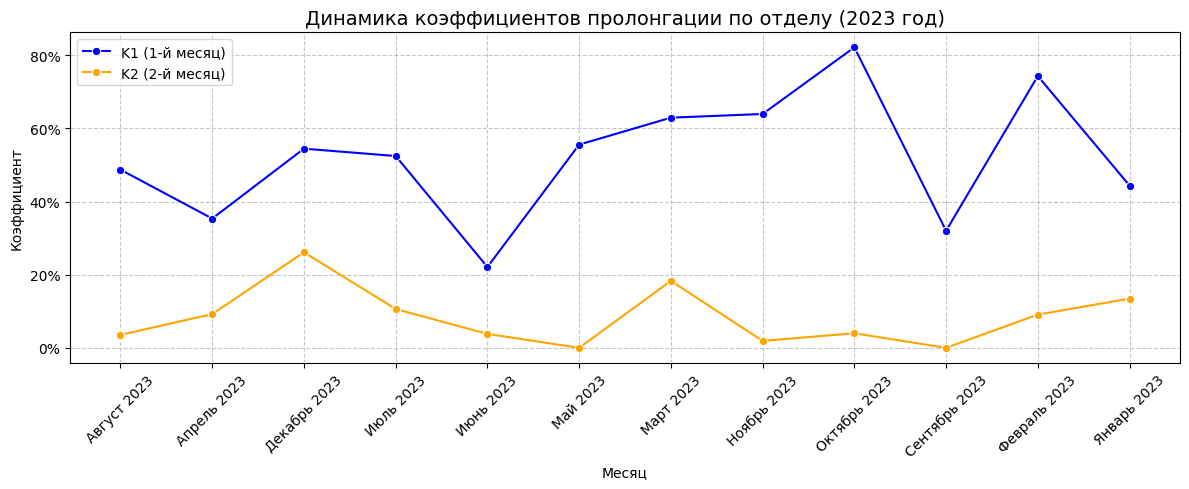

In [58]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_dept_monthly, x='Месяц отчета', y='K1', marker='o', label='K1 (1-й месяц)', color='blue')
sns.lineplot(data=df_dept_monthly, x='Месяц отчета', y='K2', marker='o', label='K2 (2-й месяц)', color='orange')

plt.title('Динамика коэффициентов пролонгации по отделу (2023 год)', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Коэффициент')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend()
plt.tight_layout()
plt.show()

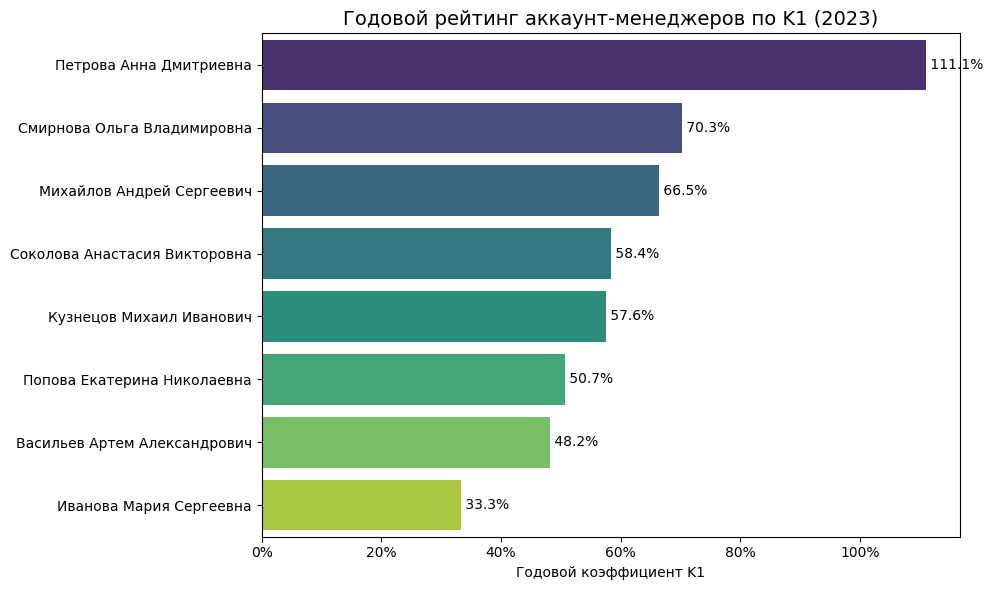

In [59]:
df_managers_yearly_sorted = df_managers_yearly.sort_values(by='K1_год', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_managers_yearly_sorted, x='K1_год', y='Менеджер', hue='Менеджер', palette='viridis')

plt.title('Годовой рейтинг аккаунт-менеджеров по K1 (2023)', fontsize=14)
plt.xlabel('Годовой коэффициент K1')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for index, value in enumerate(df_managers_yearly_sorted['K1_год']):
    plt.text(value, index, f' {value:.1%}', va='center')

plt.tight_layout()
plt.show()

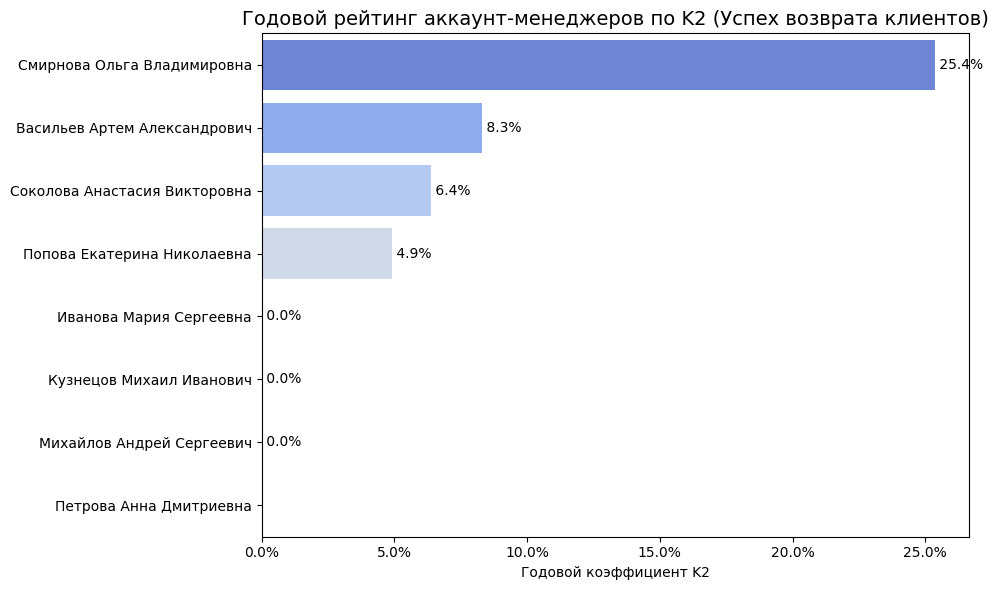

In [60]:
df_managers_yearly_sorted_k2 = df_managers_yearly.sort_values(by='K2_год', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_managers_yearly_sorted_k2, x='K2_год', y='Менеджер', hue='Менеджер', palette='coolwarm')

plt.title('Годовой рейтинг аккаунт-менеджеров по K2 (Успех возврата клиентов)', fontsize=14)
plt.xlabel('Годовой коэффициент K2')
plt.ylabel('')
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for index, value in enumerate(df_managers_yearly_sorted_k2['K2_год']):
    plt.text(value, index, f' {value:.1%}', va='center')

plt.tight_layout()
plt.show()

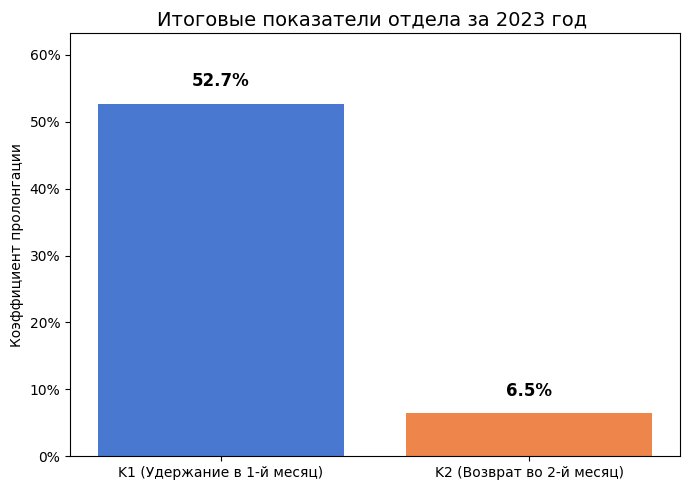

In [61]:
total_k1_num = df_metrics['K1_числитель'].sum()
total_k1_denom = df_metrics['K1_знаменатель'].sum()
total_k2_num = df_metrics['K2_числитель'].sum()
total_k2_denom = df_metrics['K2_знаменатель'].sum()

dept_k1_year = total_k1_num / total_k1_denom if total_k1_denom > 0 else 0
dept_k2_year = total_k2_num / total_k2_denom if total_k2_denom > 0 else 0

plt.figure(figsize=(7, 5))
metrics_names = ['K1 (Удержание в 1-й месяц)', 'K2 (Возврат во 2-й месяц)']
metrics_values = [dept_k1_year, dept_k2_year]

plt.bar(metrics_names, metrics_values, color=sns.color_palette('muted', n_colors=2))

plt.title('Итоговые показатели отдела за 2023 год ', fontsize=14)
plt.ylabel('Коэффициент пролонгации')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.ylim(0, max(metrics_values) * 1.2) 

for index, value in enumerate(metrics_values):
    plt.text(index, value + 0.02, f'{value:.1%}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Сохранение данных в xlsx формат

In [62]:
with pd.ExcelWriter('Отчет_пролонгация_2023_финальный.xlsx') as writer:
    pivot_k1_pct.to_excel(writer, sheet_name='K1_Эффективность_pct')
    pivot_k1_base.to_excel(writer, sheet_name='K1_База_руб')
    pivot_k2_pct.to_excel(writer, sheet_name='K2_Эффективность_pct')
    pivot_k2_base.to_excel(writer, sheet_name='K2_База_руб')
    df_managers_yearly.sort_values('Выручка_пролонгации_руб', ascending=False).to_excel(writer, sheet_name='Общий_рейтинг_год', index=False)